In [1]:
from collections import Counter
from itertools import combinations
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from datetime import datetime
from Bio import SeqIO
from Bio.Seq import Seq

from Bio import SeqIO, Phylo
from Bio.SeqRecord import SeqRecord
import subprocess
import re

from Levenshtein import distance as lev_distance 

from dnsmex.local import localify
from netam.sequences import translate_sequence, AA_STR_SORTED
from utils import sort_antibody_sites, add_cdr_shading, calculate_shannon_entropy_per_site


figures_dir = 'figures/'

### Create IMGT and Chothia reference files
Create germline codon tables for IMGT and Chothia numbering schemes.

This script downloads OGRDB germline sequences and creates codon-level dataframes
with site numbering for both IMGT and Chothia schemes.

Purpose:

We need germline annotation files for:
- In current analysis repo:
    - Add germline annotation per site (is_germline_codon/aa)
    - Annotate sites for out of frame data - ANARCI cannot be used to number these
      sequences, so for the V gene area (until CDR3) for sequences that have no
      frameshifts (filtered for earlier), we can use the germline annotation files
      to annotate the sequences according to PARTIS v gene identification
- Later this can be used for pcp generation files (pcp-pipeline) with Chothia-based
  CDRs start and end sites.

Approach:

IMGT gapped files can be downloaded from the OGRDB website.
There is no such resource for Chothia.
We create Chothia numbering with ANARCI:
- Download the ungapped version from OGRDB website
- Filter for IGHV
- Run in ANARCI with human and heavy chain parameters
- Note: Chothia uses insertion codes (e.g., 52A, 52B) while IMGT is just int-based
  for IGHV gene area

Output files:

- germline/germline_codons_imgt.csv: IMGT numbering scheme
- germline/germline_codons_chothia.csv: Chothia numbering scheme


For this analysis, we use the OGRDB reference files. 
The reference files used by partis also come from this dataset, so the two are directly comparable. The key difference is that we download the gapped version of the OGRDB references, because the gaps preserve IMGT numbering. We also compared the gene IDs and they are the same. Thus we can use the OGRDB reference to annotate the files classified by partis.

In this analysis
- We create reference files that we can later merge onto sitewise dataframes to add gemrline annotations per v gene.
- We calculate the similarities between the different v genes and plot that.

In [2]:
## create the germline codon tables for IMGT and Chothia schemes
! cd /home/nharel/re/dasm-epistasis-experiments && source ~/.bashrc && conda activate netam_env && python create_germline_codon_tables.py

LIBCIFPP_DATA_DIR has been unset
LIBCIFPP_DATA_DIR has been set to: /home/nharel/miniforge3/envs/netam_env/share/libcifpp
Creating Germline Codon Tables

### Step 1: Downloading OGRDB files ###
Gapped FASTA file germline/ogrdb_human_IGH_gapped.fasta already exists. Skipping download.
Ungapped FASTA file germline/ogrdb_human_IGH_ungapped.fasta already exists. Skipping download.

### Step 2: Creating IMGT codon table ###

=== Creating IMGT codon table ===
Verifying that gaps are codon-aligned...
✓ All gaps are codon-aligned (3 nucleotides per codon)
Loaded 198 IGHV sequences
Removing 6 genes with stop codons
IMGT codon table saved: germline/germline_codons_imgt.csv
  Rows: 18857
  Unique genes: 192

### Step 3: Preparing files for Chothia numbering ###
Filtering IGHV sequences from germline/ogrdb_human_IGH_ungapped.fasta...
Filtered 198 IGHV sequences saved to germline/ogrdb_human_IGH_ungapped_ighv.fasta
Translating sequences to amino acids...
Translated 198 sequences saved to germline/o

In [3]:
# test simialrities and differences between IMGT and Chothia germline codon tables

# Load both germline codon tables
imgt_codons = pd.read_csv(localify(f"germline/germline_codons_imgt.csv"))
chothia_codons = pd.read_csv(localify(f"germline/germline_codons_chothia.csv"))

print("=" * 80)
print("IMGT vs Chothia Germline Codon Tables Comparison")
print("=" * 80)

# Test 1: Basic statistics
print("\n=== Test 1: Basic Statistics ===")
print(f"IMGT table:")
print(f"  Rows: {len(imgt_codons):,}")
print(f"  Unique genes: {imgt_codons['v_gene'].nunique()}")
print(f"  Unique sites: {imgt_codons['site'].nunique()}")
print(f"  Site range: {imgt_codons['site'].min()} - {imgt_codons['site'].max()}")

print(f"\nChothia table:")
print(f"  Rows: {len(chothia_codons):,}")
print(f"  Unique genes: {chothia_codons['v_gene'].nunique()}")
print(f"  Unique sites: {chothia_codons['site'].nunique()}")
print(f"  Site range: {chothia_codons['site'].min()} - {chothia_codons['site'].max()}")

# Test 2: Gene overlap
print("\n=== Test 2: Gene Overlap ===")
imgt_genes = set(imgt_codons['v_gene'].unique())
chothia_genes = set(chothia_codons['v_gene'].unique())

genes_in_both = imgt_genes & chothia_genes
genes_only_imgt = imgt_genes - chothia_genes
genes_only_chothia = chothia_genes - imgt_genes

print(f"Genes in both schemes: {len(genes_in_both)}")
print(f"Genes only in IMGT: {len(genes_only_imgt)}")
if genes_only_imgt:
    print(f"  Examples: {list(genes_only_imgt)[:5]}")
print(f"Genes only in Chothia: {len(genes_only_chothia)}")
if genes_only_chothia:
    print(f"  Examples: {list(genes_only_chothia)[:5]}")

# Test 3: Site numbering differences
print("\n=== Test 3: Site Numbering Schemes ===")
print(f"IMGT sites (first 20): {sorted(imgt_codons['site'].unique())[:20]}")
print(f"Chothia sites (first 20): {sorted(chothia_codons['site'].unique())[:20]}")

# Check if Chothia has insertion codes (like 52A, 52B)
chothia_sites_with_letters = [s for s in chothia_codons['site'].unique() if any(c.isalpha() for c in str(s))]
print(f"\nChothia sites with insertion codes: {len(chothia_sites_with_letters)}")
if chothia_sites_with_letters:
    print(f"  Examples: {sorted(chothia_sites_with_letters)[:10]}")

# Test 4: Sequence alignment for shared genes
print("\n=== Test 4: Sequence Comparison for Shared Genes ===")

# Pick a gene that exists in both schemes
test_gene = list(genes_in_both)[0]
print(f"Testing with gene: {test_gene}")

imgt_gene_data = imgt_codons[imgt_codons['v_gene'] == test_gene].sort_values('site')
chothia_gene_data = chothia_codons[chothia_codons['v_gene'] == test_gene].sort_values('site')

print(f"\nIMGT sites for {test_gene}: {len(imgt_gene_data)} positions")
print(f"Chothia sites for {test_gene}: {len(chothia_gene_data)} positions")

# Compare sequences (should be identical, just numbered differently)
imgt_seq = ''.join(imgt_gene_data['amino_acid'].values)
chothia_seq = ''.join(chothia_gene_data['amino_acid'].values)

print(f"\nIMGT sequence length: {len(imgt_seq)} aa")
print(f"Chothia sequence length: {len(chothia_seq)} aa")

# Compare the overlap
min_len = min(len(imgt_seq), len(chothia_seq))
if min_len > 0:
    matches = sum(1 for i in range(min_len) if imgt_seq[i] == chothia_seq[i])
    print(f"Sequence identity (first {min_len} positions): {matches/min_len*100:.1f}%")

# Test 5: Position counts per gene
print("\n=== Test 5: Position Counts Per Gene ===")

imgt_positions_per_gene = imgt_codons.groupby('v_gene')['site'].count()
chothia_positions_per_gene = chothia_codons.groupby('v_gene')['site'].count()

print(f"IMGT - Average positions per gene: {imgt_positions_per_gene.mean():.1f}")
print(f"Chothia - Average positions per gene: {chothia_positions_per_gene.mean():.1f}")

# For shared genes, compare position counts
shared_gene_comparison = pd.DataFrame({
    'imgt_positions': imgt_positions_per_gene,
    'chothia_positions': chothia_positions_per_gene
}).dropna()

print(f"\nFor {len(shared_gene_comparison)} shared genes:")
print(f"  Average IMGT positions: {shared_gene_comparison['imgt_positions'].mean():.1f}")
print(f"  Average Chothia positions: {shared_gene_comparison['chothia_positions'].mean():.1f}")
print(f"  Genes with different position counts: {(shared_gene_comparison['imgt_positions'] != shared_gene_comparison['chothia_positions']).sum()}")

# Show some examples of genes with different position counts
different_counts = shared_gene_comparison[shared_gene_comparison['imgt_positions'] != shared_gene_comparison['chothia_positions']]
if len(different_counts) > 0:
    print(f"\nExamples of genes with different position counts:")
    print(different_counts.head(10))

# Test 6: Amino acid and codon distributions
print("\n=== Test 6: Amino Acid and Codon Distributions ===")

imgt_aa_counts = imgt_codons['amino_acid'].value_counts()
chothia_aa_counts = chothia_codons['amino_acid'].value_counts()

print(f"IMGT - Most common amino acids:")
print(imgt_aa_counts.head(5))

print(f"\nChothia - Most common amino acids:")
print(chothia_aa_counts.head(5))

# Test 7: V family distribution
print("\n=== Test 7: V Family Distribution ===")

imgt_family_counts = imgt_codons.groupby('v_family')['v_gene'].nunique()
chothia_family_counts = chothia_codons.groupby('v_family')['v_gene'].nunique()

print(f"IMGT families:")
print(imgt_family_counts.sort_index())

print(f"\nChothia families:")
print(chothia_family_counts.sort_index())

print("\n" + "=" * 80)
print("Summary:")
print("- Both tables cover overlapping but not identical gene sets")
print("- IMGT uses integer numbering, Chothia uses insertion codes (e.g., 52A)")
print("- Chothia sequences end at position 94 (end of V domain)")
print("- IMGT sequences extend further into CDR3/junction region")
print("=" * 80)

IMGT vs Chothia Germline Codon Tables Comparison

=== Test 1: Basic Statistics ===
IMGT table:
  Rows: 18,857
  Unique genes: 192
  Unique sites: 103
  Site range: 1 - 107

Chothia table:
  Rows: 18,540
  Unique genes: 189
  Unique sites: 102
  Site range: 1 - 94

=== Test 2: Gene Overlap ===
Genes in both schemes: 189
Genes only in IMGT: 3
  Examples: ['IGHV8-51-1*04', 'IGHV8-51-1*05', 'IGHV8-51-1*02']
Genes only in Chothia: 0

=== Test 3: Site Numbering Schemes ===
IMGT sites (first 20): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Chothia sites (first 20): ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27']

Chothia sites with insertion codes: 8
  Examples: ['31A', '31B', '52A', '52B', '52C', '

In [4]:
numbering_scheme = 'imgt'
numbering_scheme = 'chothia'
codons_df = pd.read_csv(localify(f"germline/germline_codons_{numbering_scheme}.csv"), dtype={'site': str})

# Sort the dataframe by site using sort_antibody_sites
sorted_sites = sort_antibody_sites(codons_df['site'].unique())
codons_df['site'] = pd.Categorical(codons_df['site'], categories=sorted_sites, ordered=True)

gapped_fasta_path = f'germline/ogrdb_human_IGH_gapped.fasta'

In [5]:

def calculate_similarity(fasta_path, level="nucleotide", metric="hamming"):
    """
    Calculate pairwise similarity between V genes from a FASTA file using nucleotides or amino acids,
    with Hamming or Levenshtein distance. Sequences of different lengths are trimmed to the shorter length.
    
    Args:
        fasta_path : str, path to FASTA file with sequences
                    - For level="nucleotide": provide nucleotide FASTA
                    - For level="aa": provide amino acid FASTA
        level : str, "nucleotide" or "aa"
        metric : str, "hamming" or "levenshtein"
        
    Returns:
        similarity_matrix : pandas DataFrame
    """
    
    # Read sequences from FASTA file
    sequences = {}
    for record in SeqIO.parse(fasta_path, "fasta"):
        if record.id.startswith('IGHV'):
            sequences[record.id] = str(record.seq).upper().replace('.', '-')

    if len(sequences) == 0:
        raise ValueError("No sequences found in FASTA file")
    
    # Use sequences as-is (no translation needed)
    seqs = sequences
    
    # Initialize similarity matrix
    gene_ids = list(seqs.keys())
    similarity_matrix = pd.DataFrame(index=gene_ids, columns=gene_ids, dtype=float)
    
    # Pairwise comparisons
    for gene1, gene2 in combinations(gene_ids, 2):
        s1, s2 = seqs[gene1], seqs[gene2]
        
        # Trim to the shorter length
        min_len = min(len(s1), len(s2))
        s1_trimmed = s1[:min_len]
        s2_trimmed = s2[:min_len]
        
        if metric == "hamming":
            # Pairwise comparison ignoring positions where either has a gap
            paired = [(a, b) for a, b in zip(s1_trimmed, s2_trimmed) if a != '-' and b != '-']
            if len(paired) == 0:
                similarity = np.nan
            else:
                identical = sum(a == b for a, b in paired)
                similarity = identical / len(paired)
        
        elif metric == "levenshtein":
            dist = lev_distance(s1_trimmed, s2_trimmed)
            max_len = max(len(s1_trimmed), len(s2_trimmed))
            similarity = 1 - (dist / max_len if max_len > 0 else 0.0)
        
        else:
            raise ValueError("metric must be 'hamming' or 'levenshtein'")
        
        similarity_matrix.loc[gene1, gene2] = similarity
        similarity_matrix.loc[gene2, gene1] = similarity
    
    # Self-similarity = 1
    np.fill_diagonal(similarity_matrix.values, 1.0)
    
    return similarity_matrix


distance_hamming_nucleotide = calculate_similarity(gapped_fasta_path, level="nucleotide", metric="hamming")
distance_hamming_aa = calculate_similarity(gapped_fasta_path, level="aa", metric="hamming")
distance_levenshtein_nucleotide = calculate_similarity(gapped_fasta_path, level="nucleotide", metric="levenshtein")
distance_levenshtein_aa = calculate_similarity(gapped_fasta_path, level="aa", metric="levenshtein")


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


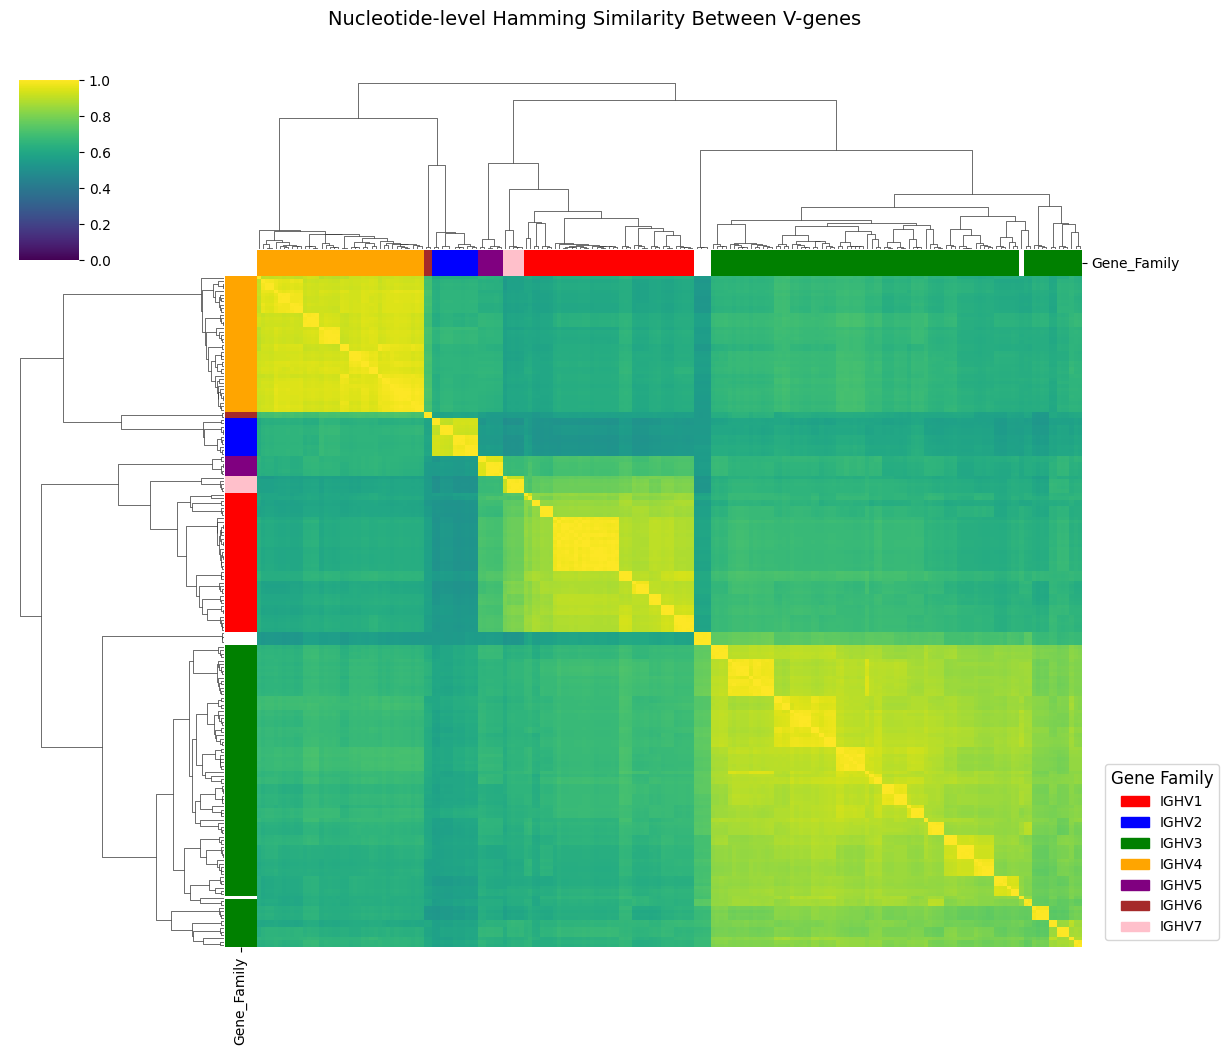

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


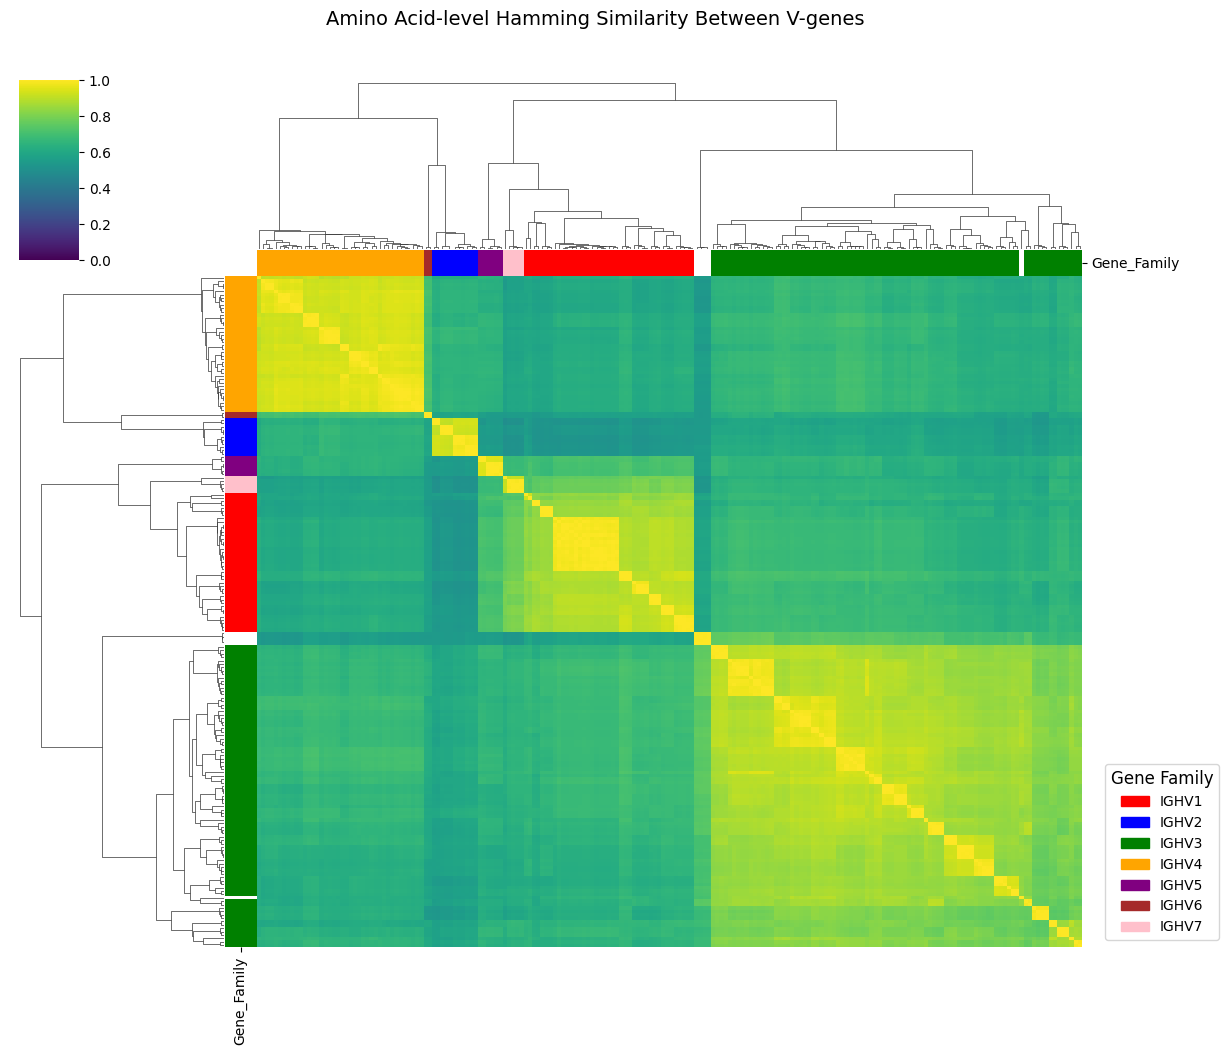

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


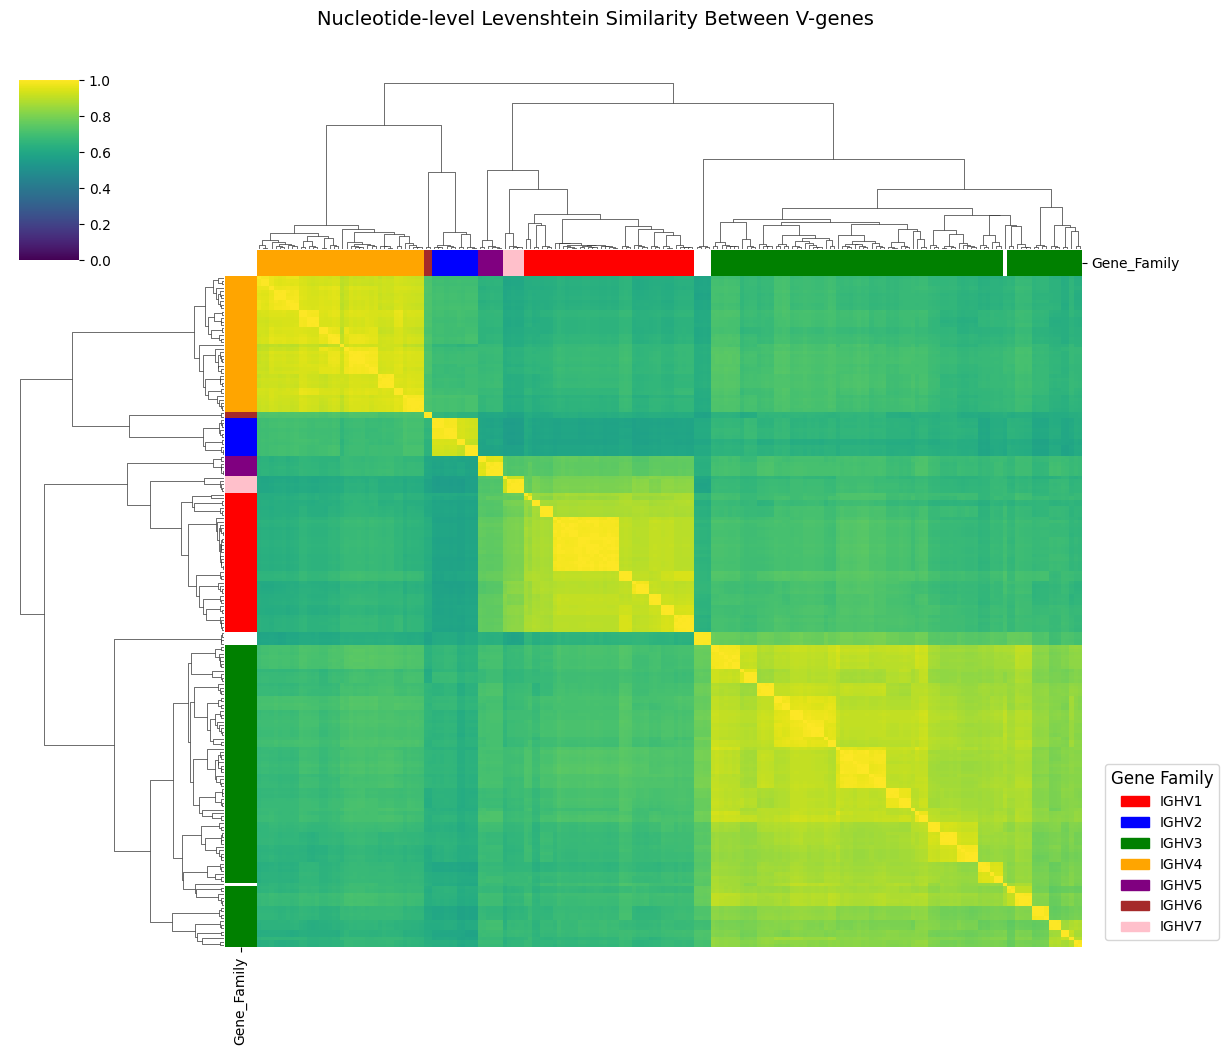

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


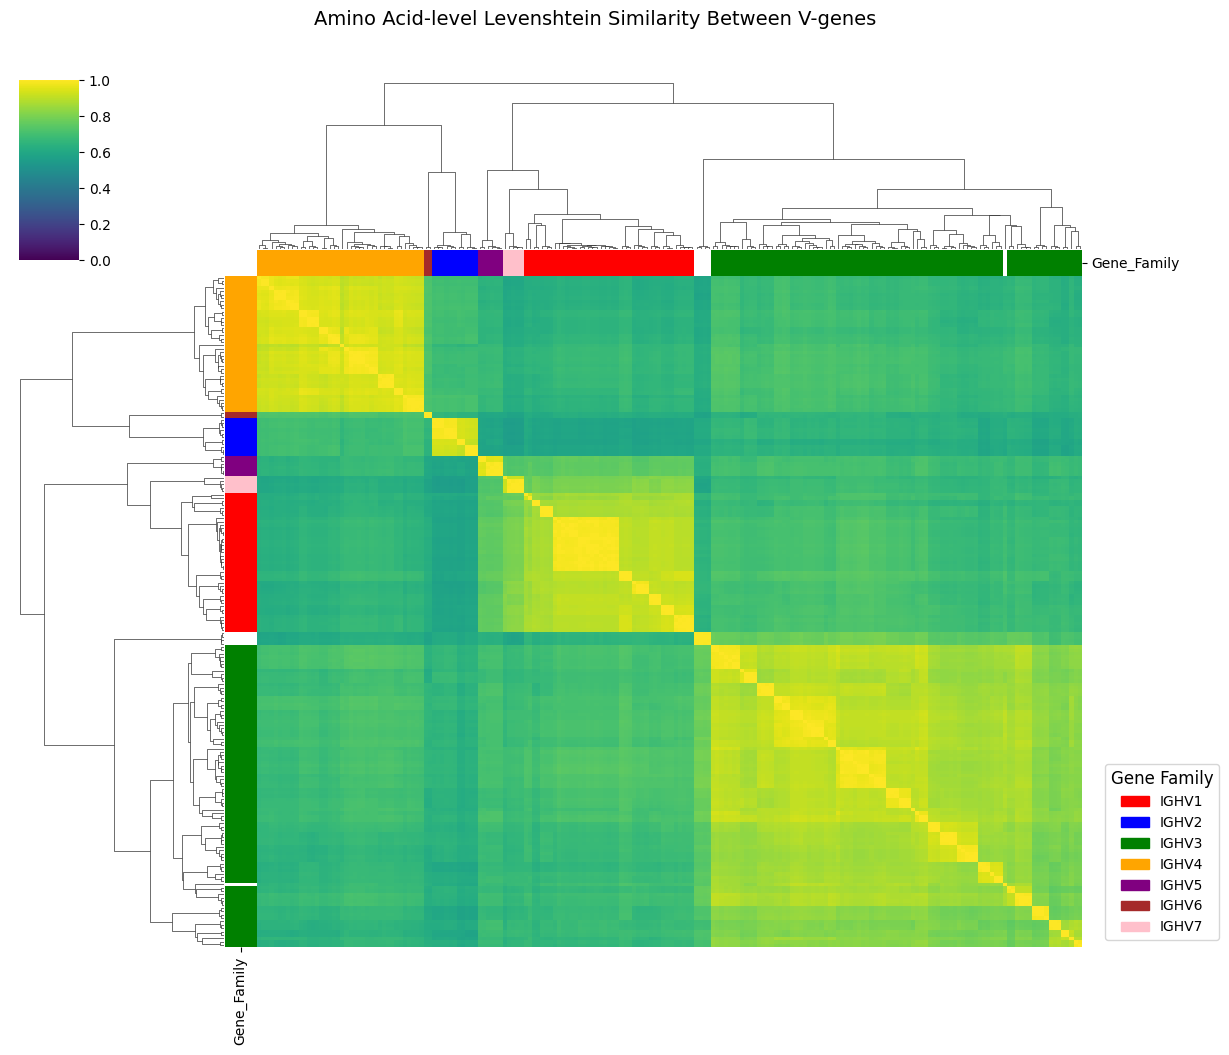

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


In [6]:


def plot_similarity_clustermap(similarity_df, codons_df, title):
    """
    Plot a clustermap of gene similarity with gene family color bars.
    
    Args:
        similarity_df : DataFrame (square similarity matrix, index = v_genes)
        codons_df : DataFrame containing ['v_gene', 'v_family']
        title : str, title for the plot
    """
    
    # --- Gene family dictionary ---
    gene_family_dict = {i[1]: i[2] 
                        for i in list(codons_df[['v_gene', 'v_family']]
                                      .drop_duplicates().itertuples())}
    
    # Clean allele info (*01, *02, etc.)
    gene_family_dict_clean = {gene.split('*')[0]: family 
                              for gene, family in gene_family_dict.items()}
    
    # Unique families → assign colors
    unique_families = sorted(set(gene_family_dict_clean.values()))
    named_colors = ['red', 'blue', 'green', 'orange', 'purple', 
                    'brown', 'pink', 'gray', 'cyan', 'olive']
    category_colors_named = dict(zip(unique_families, 
                                     named_colors[:len(unique_families)]))
    
    # Cleaned gene names for mapping
    clean_index = [gene.split('*')[0] for gene in similarity_df.index]
    clean_columns = [gene.split('*')[0] for gene in similarity_df.columns]
    
    # Row & column colors
    row_colors_df = pd.DataFrame({
        'Gene_Family': pd.Series(clean_index, index=similarity_df.index)
                          .map(gene_family_dict_clean)
                          .map(category_colors_named)
    })
    col_colors_df = pd.DataFrame({
        'Gene_Family': pd.Series(clean_columns, index=similarity_df.columns)
                          .map(gene_family_dict_clean)
                          .map(category_colors_named)
    })
    
    # --- Clustermap ---
    g = sns.clustermap(similarity_df,
                       cmap='viridis',
                       square=True,
                       xticklabels=False,
                       yticklabels=False,
                       row_colors=row_colors_df,
                       col_colors=col_colors_df,
                       figsize=(12, 10),
                       vmin=0, vmax=1)
    
    # Title
    g.fig.suptitle(title, fontsize=14, y=1.05)
    
    # Legend for families
    legend_patches = [mpatches.Patch(color=color, label=family) 
                      for family, color in sorted(category_colors_named.items())]
    
    g.ax_heatmap.legend(handles=legend_patches,
                        bbox_to_anchor=(1.02, 0), 
                        loc='lower left',
                        title='Gene Family',
                        title_fontsize=12,
                        fontsize=10)
    
    plt.show()
    
    # Print mapping for reproducibility
    print("Gene family color mapping:")
    for family, color in sorted(category_colors_named.items()):
        print(f"{family}: {color}")

# --- Use it for your 4 similarity matrices ---
plot_similarity_clustermap(distance_hamming_nucleotide, codons_df, 
                           "Nucleotide-level Hamming Similarity Between V-genes")

plot_similarity_clustermap(distance_hamming_aa, codons_df, 
                           "Amino Acid-level Hamming Similarity Between V-genes")

plot_similarity_clustermap(distance_levenshtein_nucleotide, codons_df, 
                           "Nucleotide-level Levenshtein Similarity Between V-genes")

plot_similarity_clustermap(distance_levenshtein_aa, codons_df, 
                           "Amino Acid-level Levenshtein Similarity Between V-genes")


In [7]:
distance_levenshtein_aa.reset_index()

,index,IGHV1-18*01,IGHV1-18*03,IGHV1-18*04,IGHV1-2*02,IGHV1-2*04,IGHV1-2*05,IGHV1-2*06,IGHV1-2*07,IGHV1-24*01,...,IGHV6-1*03,IGHV7-4-1*01,IGHV7-4-1*02,IGHV7-4-1*04,IGHV7-4-1*05,IGHV7-81*01,IGHV8-51-1*02,IGHV8-51-1*03,IGHV8-51-1*04,IGHV8-51-1*05
0,IGHV1-18*01,1.000000,0.996875,0.996875,0.918750,0.915625,0.912500,0.915625,0.915625,0.862500,...,0.628125,0.809375,0.812500,0.809375,0.806250,0.818750,0.646875,0.650000,0.646875,0.643750
1,IGHV1-18*03,0.996875,1.000000,0.993750,0.915625,0.912500,0.909375,0.912500,0.912500,0.859375,...,0.625000,0.806250,0.809375,0.806250,0.803125,0.821875,0.650000,0.653125,0.650000,0.646875
2,IGHV1-18*04,0.996875,0.993750,1.000000,0.921875,0.918750,0.915625,0.918750,0.918750,0.859375,...,0.628125,0.806250,0.809375,0.806250,0.803125,0.815625,0.643750,0.646875,0.643750,0.640625
3,IGHV1-2*02,0.918750,0.915625,0.921875,1.000000,0.996875,0.993750,0.996875,0.996875,0.875000,...,0.618750,0.828125,0.831250,0.828125,0.825000,0.815625,0.637500,0.640625,0.637500,0.634375
4,IGHV1-2*04,0.915625,0.912500,0.918750,0.996875,1.000000,0.990625,0.993750,0.993750,0.871875,...,0.621875,0.828125,0.831250,0.828125,0.825000,0.815625,0.634375,0.637500,0.634375,0.631250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,IGHV7-81*01,0.818750,0.821875,0.815625,0.815625,0.815625,0.809375,0.812500,0.812500,0.762500,...,0.593750,0.918750,0.921875,0.918750,0.915625,1.000000,0.600000,0.600000,0.600000,0.596875
194,IGHV8-51-1*02,0.646875,0.650000,0.643750,0.637500,0.634375,0.634375,0.637500,0.640625,0.653125,...,0.581250,0.581250,0.584375,0.587500,0.587500,0.600000,1.000000,0.993750,0.996875,0.993750
195,IGHV8-51-1*03,0.650000,0.653125,0.646875,0.640625,0.637500,0.637500,0.640625,0.643750,0.656250,...,0.584375,0.584375,0.587500,0.590625,0.590625,0.600000,0.993750,1.000000,0.996875,0.993750
196,IGHV8-51-1*04,0.646875,0.650000,0.643750,0.637500,0.634375,0.634375,0.637500,0.640625,0.653125,...,0.584375,0.581250,0.584375,0.587500,0.587500,0.600000,0.996875,0.996875,1.000000,0.996875


## Figures

In [8]:
# reload codon_df without categorical
numbering_scheme = 'chothia'
codons_df = pd.read_csv(localify(f"germline/germline_codons_{numbering_scheme}.csv"), dtype={'site': str})

# Sort the dataframe by site using sort_antibody_sites
sorted_sites = sort_antibody_sites(codons_df['site'].unique())


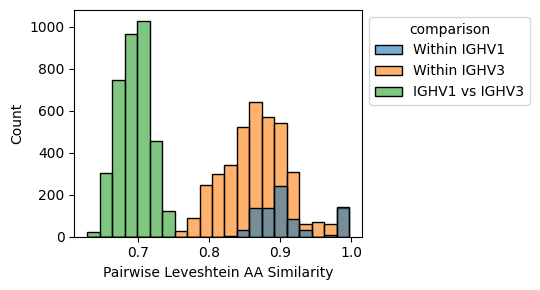

In [9]:
def plot_vfamily_similarity(similarity_df, v_families, title="V-gene Similarity Distributions", save_path=None):
    """
    Plot overlapping pairwise similarity histograms for a list of V families.

    Shows within-family and cross-family distributions on a single axis
    with consistent bin widths via a unified dataframe and seaborn hue.

    Parameters
    ----------
    similarity_df : DataFrame
        Square similarity matrix with v_gene names as index/columns.
    v_families : list of str
        V families to compare (e.g., ['IGHV1', 'IGHV3', 'IGHV4']).
    title : str
        Title for the figure.
    save_path : str, optional
        If provided, saves the figure to this path.
    """
    pw = (similarity_df
          .reset_index()
          .rename(columns={'index': 'v_gene1'})
          .melt(id_vars=['v_gene1'], var_name='v_gene2', value_name='similarity'))
    pw = pw[pw['v_gene1'] != pw['v_gene2']]
    pw['v_family1'] = pw['v_gene1'].str.split('-').str[0]
    pw['v_family2'] = pw['v_gene2'].str.split('-').str[0]

    pw = pw[pw['v_gene1'] < pw['v_gene2']]
    
    within_pairs = [(f, f) for f in v_families]
    cross_pairs = list(combinations(v_families, 2))

    rows = []
    for f1, f2 in within_pairs + cross_pairs:
        if f1 == f2:
            mask = (pw['v_family1'] == f1) & (pw['v_family2'] == f1)
            label = f"Within {f1}"
        else:
            mask = (
                ((pw['v_family1'] == f1) & (pw['v_family2'] == f2)) |
                ((pw['v_family1'] == f2) & (pw['v_family2'] == f1))
            )
            label = f"{f1} vs {f2}"
        subset = pw.loc[mask, ['similarity']].copy()
        subset['comparison'] = label
        rows.append(subset)

    plot_df = pd.concat(rows, ignore_index=True)

    fig, ax = plt.subplots(figsize=(5.5, 3))
    sns.histplot(data=plot_df, x='similarity', hue='comparison', ax=ax,
                 alpha=0.6, common_bins=True, stat='count', common_norm=False)
    ax.set_xlabel("Pairwise Leveshtein AA Similarity")
    ax.set_title(title)
    # move legend to the right of the plot
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()


plot_vfamily_similarity(distance_levenshtein_aa, ['IGHV1', 'IGHV3'], title='', save_path=f"{figures_dir}v_family_pairwise_similarity.png")


In [10]:
def plot_shannon_entropy_per_site(germline_codons_df, v_families=None, title=None, save_fig=False):
    """
    Plot Shannon entropy per site using calculate_shannon_entropy_per_site from utils.
    """
    entropy_results = calculate_shannon_entropy_per_site(germline_codons_df, v_families=v_families)
    sorted_sites = sort_antibody_sites(entropy_results['site'].unique())
    entropy_results['site'] = pd.Categorical(entropy_results['site'], categories=sorted_sites, ordered=True)

    fig, ax = plt.subplots(1, 1, figsize=(7, 1.8))
    sns.lineplot(entropy_results, x='site', y='shannon_entropy', color='black', alpha=0.9)
    ax.set_ylabel("Shannon Entropy", fontsize=14)
    ax.set_xlabel("Site", fontsize=14)
    add_cdr_shading(ax, numbering_scheme=numbering_scheme, sorted_sites=sorted_sites)
    tick_positions = list(range(9, len(sorted_sites), 10))
    tick_labels = [sorted_sites[i] for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_ylim(0, np.log2(entropy_results['n_unique_aa'].max() + 1))
    if title is None:
        plt.title(f"Shannon Entropy per Germline Site for {v_families}", fontsize=14)
    else:
        plt.title(title, fontsize=14)

    if save_fig:
        fig.savefig(f"figures/shannon_entropy_{'_'.join(v_families) if v_families else 'all'}.png", bbox_inches='tight', dpi=800)
    fig.show()
    return entropy_results

,site,shannon_entropy,n_unique_aa,n_germlines
0,1,1.051089,3,126
1,10,1.127887,3,126
2,11,1.057698,3,126
3,12,1.156535,4,126
4,13,1.192385,4,126
...,...,...,...,...
95,90,0.000000,1,126
96,91,0.162326,2,126
97,92,0.000000,1,126
98,93,0.770477,4,126


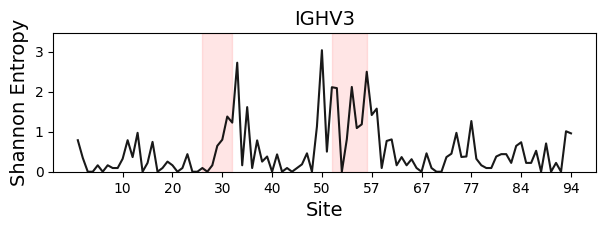

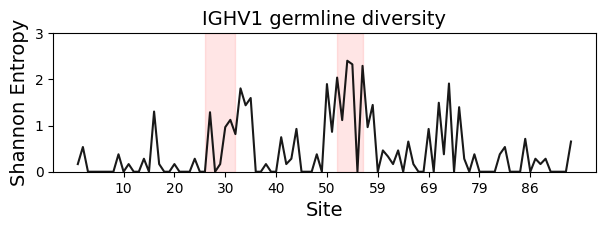

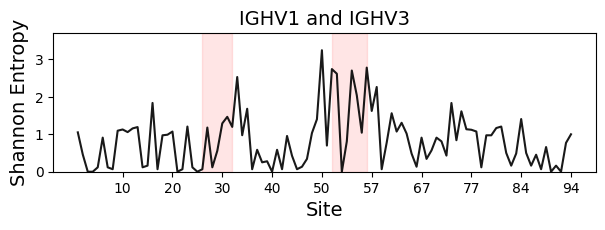

In [11]:

plot_shannon_entropy_per_site(germline_codons_df=codons_df, v_families=['IGHV3'], title='IGHV3')
plot_shannon_entropy_per_site(germline_codons_df=codons_df, v_families=['IGHV1'], title='IGHV1 germline diversity', save_fig=True)
plot_shannon_entropy_per_site(germline_codons_df=codons_df, v_families=['IGHV1', 'IGHV3'], title='IGHV1 and IGHV3')

In [12]:
import logomaker

PALETTE_AA = dict(zip(AA_STR_SORTED, sns.color_palette('tab20', len(AA_STR_SORTED))))


def plot_germline_logo(codons_df, v_family, site_start, site_end,
                       title=None, ax=None, figsize=None, save_path=None):
    """
    Plot a sequence logo for germline amino acid preferences across a V family.

    Parameters
    ----------
    codons_df : DataFrame
        Germline codon table with columns: 'site', 'v_gene', 'v_family', 'amino_acid'.
        Sites should be strings.
    v_family : str
        V family to plot (e.g., 'IGHV3').
    site_start : int or str
        First site to include (inclusive).
    site_end : int or str
        Last site to include (inclusive).
    numbering_scheme : str
        'imgt' or 'chothia' (used for CDR shading and site sorting).
    ax : matplotlib Axes, optional
        Axes to draw on. If None, creates a new figure.
    figsize : tuple, optional
        Figure size. Defaults to (max(len(sites), 6), 2.5).

    Returns
    -------
    ax : matplotlib Axes
    """
    df = codons_df[codons_df['v_family'] == v_family].copy()
    df['site'] = df['site'].astype(str)

    # Get all sites in proper order, then select the requested range
    all_sorted = sort_antibody_sites(df['site'].unique())
    start_str, end_str = str(site_start), str(site_end)
    try:
        i_start = all_sorted.index(start_str)
        i_end = all_sorted.index(end_str)
    except ValueError:
        raise ValueError(
            f"site_start={site_start} or site_end={site_end} not found in "
            f"available sites for {v_family}. Available: {all_sorted}"
        )
    selected_sites = all_sorted[i_start:i_end + 1]
    df = df[df['site'].isin(selected_sites)]

    # Build a frequency matrix: rows = sites, columns = amino acids
    freq_rows = []
    for site in selected_sites:
        site_data = df[df['site'] == site]['amino_acid']
        counts = site_data.value_counts()
        total = counts.sum()
        freq_rows.append({aa: counts.get(aa, 0) / total for aa in AA_STR_SORTED})

    freq_df = pd.DataFrame(freq_rows, index=range(len(selected_sites)))

    # Create logo
    if ax is None:
        if figsize is None:
            figsize = (max(len(selected_sites), 6), 2.5)
        fig, ax = plt.subplots(figsize=figsize)

    logo = logomaker.Logo(
        freq_df,
        color_scheme=PALETTE_AA,
        ax=ax,
        font_name='DejaVu Sans',
        stack_order='big_on_top',
    )

    # Use the actual site labels on the x-axis
    ax.set_xticks(range(len(selected_sites)))
    ax.set_xticklabels(selected_sites, fontsize=20)
    ax.set_xlabel('Site', fontsize=20)
    ax.set_ylabel('Germline\namino acid', fontsize=20)
    ax.set_yticklabels([])
    if title:
        ax.set_title(title, fontsize=18)

    # Clean up spines
    sns.despine(ax=ax, trim=True)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    return ax

<Axes: xlabel='Site', ylabel='Germline\namino acid'>

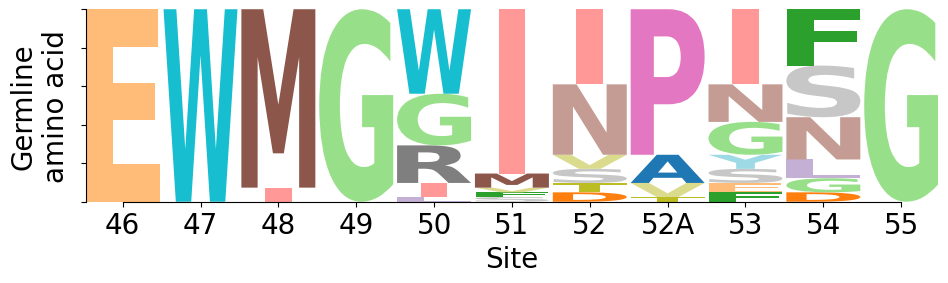

In [13]:
# ensure codons_df sites are strings for the logo function
codons_df['site'] = codons_df['site'].astype(str)

plot_germline_logo(codons_df, v_family='IGHV1', site_start='46', site_end='55', save_path=f'figures/germline_logo_IGHV1_46-55.png')